In [1]:
# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn models & utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [2]:
# Example: Using Kaggle Housing dataset
df = pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')  # Replace with your file path
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
df = df.dropna()  # Simple way
# Or impute: df.fillna(df.mean(), inplace=True)

In [7]:
# Split features & target
X = df.drop('median_house_value', axis=1)  # Features
y = df['median_house_value']               # Target

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split train & test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Standardize features (for SVM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 69297.7166911303
Linear Regression R2: 0.6488402154431994


In [9]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree RMSE: 67296.33003700843
Decision Tree R2: 0.6688309933664495


In [10]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 48767.9945206636
Random Forest R2: 0.8260851299316047


In [11]:
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)
y_pred_svr = svm_model.predict(X_test_scaled)

print("SVR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print("SVR R2:", r2_score(y_test, y_pred_svr))

SVR RMSE: 119708.47882976035
SVR R2: -0.04789253816334549


In [12]:
# AdaBoost
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [13]:
# Example: Random Forest Grid Search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
y_pred_rf_tuned = grid_rf.predict(X_test)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'AdaBoost', 'Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ada)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_ada),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,69297.716691,0.648840
1,Decision Tree,67296.330037,0.668831
2,Random Forest,48767.994521,0.826085
3,SVR,119708.478830,-0.047893
4,AdaBoost,87035.280488,0.446067
5,Gradient Boosting,56565.434123,0.766025


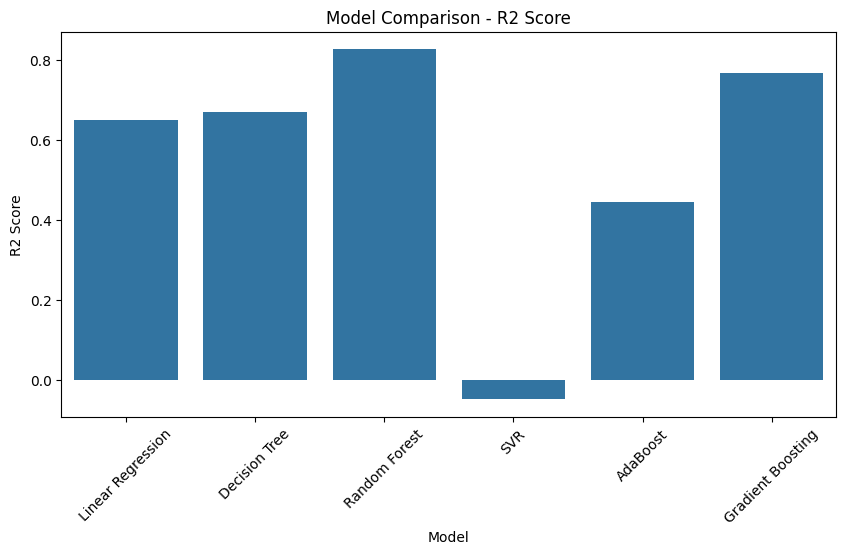

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.xticks(rotation=45)
plt.title("Model Comparison - R2 Score")
plt.show()